In [1]:
%pip install -r ../requirements.txt -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.2.0 requires pandas<3,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
otter-grader 6.1.3 requires wrapt<2.0.0,>=1.16.0, but you have wrapt 2.1.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from eep153_tools.sheets import read_sheets


In [3]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing
    
    y = x

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d


In [5]:
y, d = prepare_data(NG_URL, "Food Expenditures (2016Q1)")

In [6]:
log_y = np.log(y)

In [7]:
log_y = log_y.stack().dropna()

d = d.stack().dropna()

In [8]:
from cfe import Regression as rgsn

result = rgsn(y=log_y,d=d)

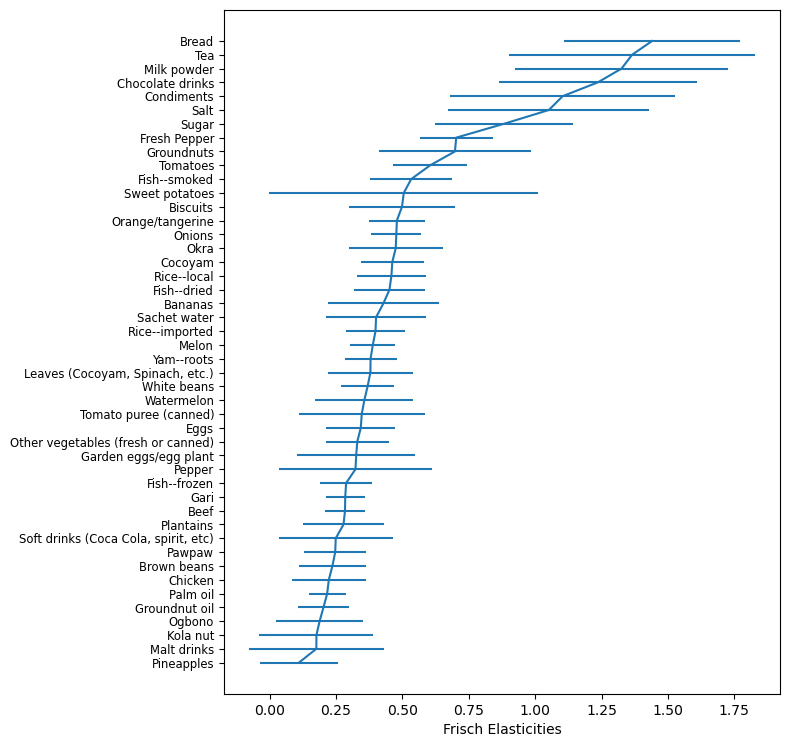

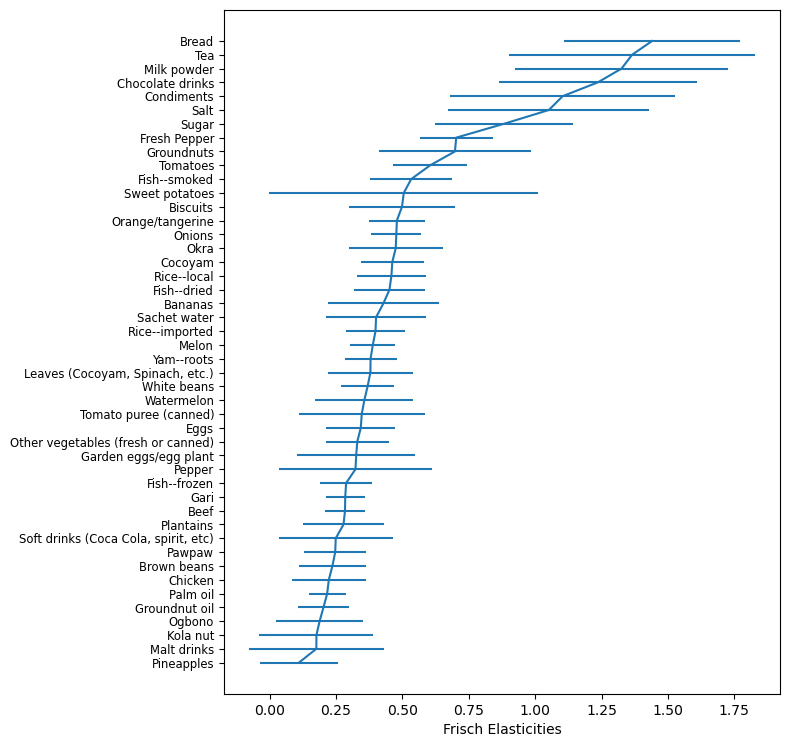

In [9]:
result.graph_beta()

In [10]:
FCT = pd.read_csv("../data/NigerianFCT.csv")

In [11]:
FCT = FCT.rename(columns = {'Unnamed: 0' : 'j'})

FCT = FCT.set_index('j')

FCT = FCT.apply(lambda x: pd.to_numeric(x,errors='coerce'))

FCT = FCT.fillna(0)

In [12]:
RDI = pd.read_csv('../data/NigerianRDI.csv')

RDI = RDI.set_index('n')
RDI.columns.name = 'k'


In [13]:
p = read_sheets(NG_URL, sheet = "Food Prices (2016Q1)")

In [14]:
pbar = p.groupby('j')['Price'].mean()
pbar = pbar[result.beta.index] # Only use prices for goods we can estimate

In [15]:
xhat = result.predicted_expenditures()

# Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()

# Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

In [16]:
qhat = (xhat.unstack('j')/pbar).dropna(how='all')

# Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

qhat

,,j,Bananas,Beef,Biscuits,Bread,Brown beans,Chicken,Chocolate drinks,Cocoyam,Condiments,Eggs,...,Salt,"Soft drinks (Coca Cola, spirit, etc)",Sugar,Sweet potatoes,Tea,Tomato puree (canned),Tomatoes,Watermelon,White beans,Yam--roots
i,t,m,,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,1.115353,0.985875,0.175078,1.252425,1.356521,1.430572,0.135295,1.441031,0.184704,0.137128,...,0.168322,1.038487,0.115192,1.837988,0.027959,0.223161,1.135049,4.834810,1.296786,10.758984
10002,2016Q1,south east,1.331909,1.208527,0.229007,3.733499,1.350642,1.722139,0.318005,2.068230,0.360398,0.158007,...,0.412763,1.084841,0.221322,3.304496,0.087541,0.235269,1.726713,5.940646,1.672820,15.378039
10003,2016Q1,south east,1.118062,1.026274,0.126578,1.129347,1.075674,1.395224,0.127088,1.503929,0.168574,0.116121,...,0.158253,1.097295,0.122061,2.469352,0.041353,0.209090,1.014862,4.810767,1.358221,11.437190
10004,2016Q1,south east,1.078760,0.970528,0.109292,1.592027,1.096141,1.388063,0.131934,1.461382,0.153226,0.097985,...,0.159837,0.998702,0.111994,2.812724,0.043796,0.187149,1.094369,5.287222,1.244191,11.718531
10005,2016Q1,south east,1.450775,1.055790,0.164304,1.312352,1.416582,1.277544,0.158789,1.711149,0.336489,0.155609,...,0.231416,1.228779,0.181754,2.225617,0.085083,0.163653,1.219287,5.660818,1.597103,13.385565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2016Q1,north central,0.930348,1.000908,0.145251,0.588576,1.509571,1.222790,0.082811,1.486383,0.130756,0.182843,...,0.162007,1.152854,0.206812,1.313890,0.051965,0.272673,0.759420,5.349193,1.775075,14.254794
370037,2016Q1,north central,0.359876,0.486750,0.041617,0.031328,0.849293,0.825129,0.005373,0.539710,0.014311,0.075280,...,0.015986,0.679790,0.027195,0.501567,0.003955,0.111120,0.214441,2.757805,0.785947,6.090452
370038,2016Q1,north central,0.421751,0.594080,0.055121,0.091040,1.012993,0.882402,0.013922,0.629720,0.022794,0.092058,...,0.025699,0.719588,0.043142,0.674491,0.012837,0.125185,0.321005,3.460177,0.917241,7.078883


In [17]:
def my_prices(p0, p=pbar, j=None):
    p = p.copy()
    if j is not None:
        p.loc[j] = p0
    return p

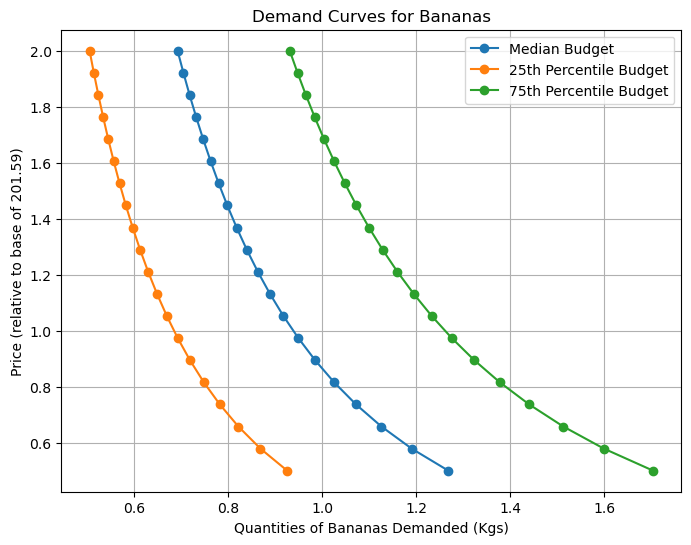

In [18]:

%matplotlib inline

plt.close('all')          # optional: closes old figures
plt.figure(figsize=(8,6)) # start a new clean figure

use = 'Bananas'   # Good we want demand curve for
scale = np.linspace(0.5, 2, 20)

plt.close('all')
plt.figure(figsize=(8,6))

# Median budget household
median_demands = [
    result.demands(
        xref,
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# 25th percentile household
q25_demands = [
    result.demands(
        xbar.quantile(0.25),
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# 75th percentile household
q75_demands = [
    result.demands(
        xbar.quantile(0.75),
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# Plot all three demand curves
plt.plot(median_demands, scale, marker='o', label='Median Budget')
plt.plot(q25_demands, scale, marker='o', label='25th Percentile Budget')
plt.plot(q75_demands, scale, marker='o', label='75th Percentile Budget')

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded (Kgs)")
plt.title(f"Demand Curves for {use}")
plt.legend()
plt.grid(True)

plt.show()


/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -2.98E-08.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps tolerance is too high?" % (tol,x[0]-x[-1],i))
/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -7.45E-09.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps tolerance is too high?" % (tol,x[0]-x[-1],i))
/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -3.73E-09.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps toleranc

Text(0.5, 1.0, 'Engel Curves')

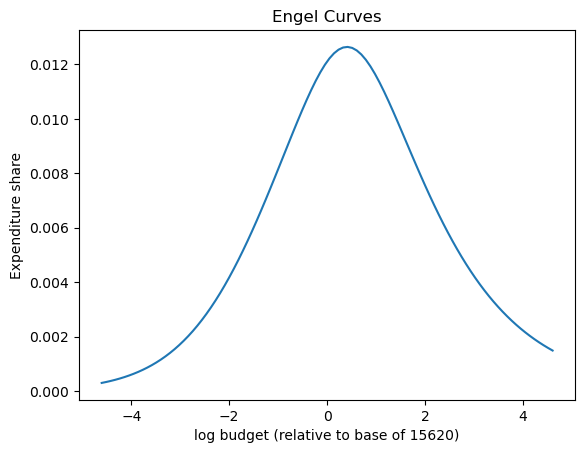

In [19]:
fig,ax = plt.subplots()

scale = np.geomspace(0.01,100,100)
ax.plot(np.log(scale),[(result.expenditures(s*xref,pbar)/(s*xref))['Bananas'] for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')

In [20]:
# Create a new FCT and vector of consumption that only share rows in common:
# Convert FCT index to string so it can match 'Bananas'
fct0,c0 = FCT.align(qhat.T,axis=0,join='inner')
print(fct0.index)

Index(['Malt drinks', 'Soft drinks (Coca Cola, spirit, etc)', 'Plantains',
       'Yam--roots', 'Milk powder', 'Chicken', 'Condiments', 'Tea',
       'Sachet water', 'Palm oil', 'Chocolate drinks', 'Tomato puree (canned)',
       'Fish--frozen', 'Eggs', 'Bread', 'Groundnut oil', 'Beef', 'Fish--dried',
       'Rice--local', 'Sweet potatoes', 'Fish--smoked', 'Gari', 'Sugar',
       'Onions', 'Groundnuts', 'White beans', 'Pepper', 'Bananas', 'Tomatoes',
       'Other vegetables (fresh or canned)', 'Rice--imported', 'Brown beans',
       'Okra', 'Leaves (Cocoyam, Spinach, etc.)'],
      dtype='str', name='j')


In [21]:
FCT

,Alanine,"Alcohol, ethyl",Amino acids,Arginine,Ash,Aspartic acid,Betaine,Caffeine,"Calcium, Ca","Carbohydrate, by difference",...,Vitamin D2 (ergocalciferol),Vitamin D3 (cholecalciferol),Vitamin E (alpha-tocopherol),"Vitamin E, added",Vitamin K (Dihydrophylloquinone),Vitamin K (Menaquinone-4),Vitamin K (phylloquinone),Vitamins and Other Components,Water,"Zinc, Zn"
j,,,,,,,,,,,,,,,,,,,,,
Malt drinks,0.000,0.0,0.0,0.000,1.90,0.000,0.0,37.0,60.00,86.940000,...,0.0,0.0,0.17,0.00,0.0,0.0,2.5,0.0,1.30,0.8000
"Soft drinks (Coca Cola, spirit, etc)",0.000,0.0,0.0,0.000,0.00,0.000,0.0,9.0,1.00,10.400000,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,89.40,0.0900
Plantains,0.000,0.0,0.0,0.000,0.00,0.000,0.0,0.0,9.00,63.800000,...,0.0,0.0,5.04,0.00,0.0,0.0,28.6,0.0,2.09,0.3700
Yam--roots,0.063,0.0,0.0,0.127,0.82,0.155,0.0,0.0,17.00,27.880000,...,0.0,0.0,0.35,0.00,0.0,0.0,2.3,0.0,69.60,0.2400
Milk powder,0.000,0.0,0.0,0.000,0.00,0.000,0.0,0.0,1292.00,54.170000,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0000
Chicken,0.000,0.0,0.0,0.000,0.00,0.000,0.0,0.0,0.00,1.180000,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0000
Condiments,0.000,0.0,0.0,0.000,2.05,0.000,0.0,0.0,106.00,14.430000,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,50.34,3.3300
Tea,0.000,0.0,0.0,0.000,0.00,0.000,0.0,0.0,0.00,8.460000,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0000
Sachet water,0.000,0.0,0.0,0.000,0.00,0.000,0.0,0.0,3.00,0.000000,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,99.90,0.0100


In [22]:
# The @ operator means matrix multiply
N = fct0.T@c0

N  #NB: Uganda quantities are for previous 7 days

i,10001,10002,10003,10004,10005,10008,10009,10010,10011,10012,...,370031,370032,370033,370034,370035,370036,370037,370038,370039,370040
t,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,...,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1,2016Q1
m,south east,south east,south east,south east,south east,south east,south east,south east,south east,south east,...,north central,north central,north central,north central,north central,north central,north central,north central,north central,north central
Alanine,7.369151,9.365964,7.806358,7.217016,8.998588,8.729311,6.663479,7.222482,9.048419,9.436684,...,5.836641,12.312202,3.759259,4.124300,5.535965,6.951127,2.749007,3.287053,6.575647,7.154451
"Alcohol, ethyl",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Amino acids,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Arginine,8.584265,10.903753,9.155598,8.354415,10.501434,10.323423,7.763538,8.257296,10.417977,11.331796,...,7.540433,15.631697,4.733798,5.175734,6.763869,8.584670,3.438432,4.078131,8.208692,9.007767
Ash,30.300858,39.729891,32.230980,30.920747,36.401122,34.220776,26.356739,30.982510,37.026464,35.568210,...,26.247825,48.480004,18.032279,20.805861,26.579454,32.437253,13.717820,16.037947,31.665261,32.735851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vitamin K (Menaquinone-4),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Vitamin K (phylloquinone),89.132246,110.456098,93.594465,88.899567,111.694279,98.255981,77.743610,83.846039,105.696671,118.143582,...,101.950618,168.281326,64.812457,80.408485,86.228258,99.532723,51.807602,61.187656,110.036204,117.888849


In [23]:
def nutrient_demand(x,p,r=result,fct=FCT):
    c = result.demands(x,p)
    fct0,c0 = FCT.align(c,axis=0,join='inner')
    N = fct0.T@c0

    # Drop duplicate nutrient rows (keeps first).  If your FCT has
    # duplicates this silently discards data; worth checking with
    # fct.index[fct.index.duplicated()] to see what's being dropped.
    N = N.loc[~N.index.duplicated()]

    return N

/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = geta

Text(0, 0.5, 'log nutrient')

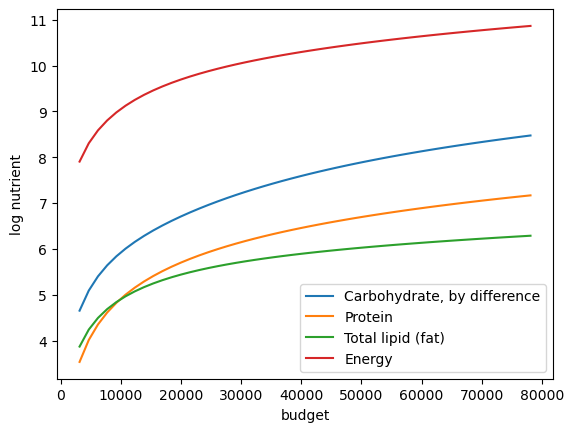

In [24]:
X = np.linspace(xref/5,xref*5,50)

UseNutrients = ['Carbohydrate, by difference', 'Protein',
       'Total lipid (fat)', 'Energy']

df = pd.concat({myx:np.log(nutrient_demand(myx,pbar))[UseNutrients] for myx in X},axis=1).T
ax = df.plot()

ax.set_xlabel('budget')
ax.set_ylabel('log nutrient')

In [25]:
def ceteris_paribus_price(j,p0,p=pbar):
    """
    Return price vector with the price of good j set to p0,
    holding all other prices fixed at p.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = geta

Text(0, 0.5, 'log nutrient')

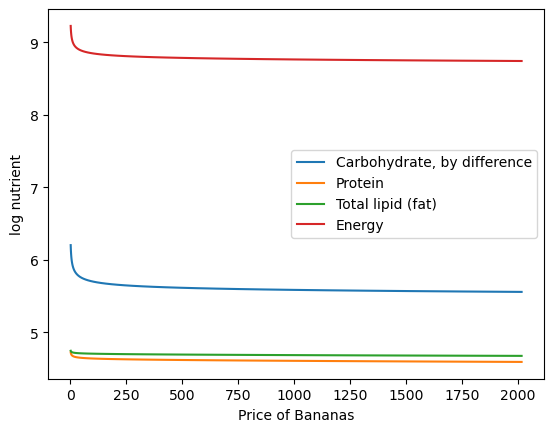

In [26]:
USE_GOOD = 'Bananas'

scale = np.geomspace(.01,10,50)

ndf = pd.DataFrame({s*pbar[USE_GOOD]:np.log(nutrient_demand(xref/2,ceteris_paribus_price(USE_GOOD,pbar[USE_GOOD]*s)))[UseNutrients] for s in scale}).T

ax = ndf.plot()

ax.set_xlabel(f'Price of {USE_GOOD}')
ax.set_ylabel('log nutrient')

In [27]:
# In first round, averaged over households and villages
mapping = {
    'Females 00-03': 'Female 00-03',
    'Males 00-03':   'Male 00-03',
    'Females 04-08': 'Female 04-08',
    'Males 04-08':   'Male 04-08',
    'Females 09-13': 'Female 09-13',
    'Males 09-13':   'Male 09-13',
    'Females 14-18': 'Female 14-18',
    'Males 14-18':   'Male 14-18',
    'Females 19-30': 'Female 19-30',
    'Males 19-30':   'Male 19-30',
    'Females 31-50': 'Female 31-50',
    'Males 31-50':   'Male 31-50',
    'Females 51-99': 'Female 51+',
    'Males 51-99':   'Male 51+'
}

RDI = RDI.rename(columns=mapping)

dbar = result.d[RDI.columns].mean()

In [28]:
dbar

k
Female 00-03    0.246937
Male 00-03      0.265316
Female 04-08    0.416824
Male 04-08      0.439208
Female 09-13    0.420358
Male 09-13      0.465834
Female 14-18    0.303723
Male 14-18      0.388077
Female 19-30    0.509661
Male 19-30      0.477851
Female 31-50    0.622997
Male 31-50      0.429076
Female 51+      0.368049
Male 51+        0.396560
dtype: float64

In [29]:
# This matrix product gives minimum nutrient requirements for
# the average household
hh_rdi = RDI@dbar

hh_rdi

n
Energy          10152.403393
Protein           229.233506
Fiber             142.133648
Folate           1912.299717
Calcium          6143.803016
Carbohydrate      747.561263
Iron               61.820452
Magnesium        1646.439680
Niacin             72.883129
Phosphorus       4599.078699
Potassium       25208.718190
Riboflavin          5.720853
Thiamin             5.551697
Vitamin A        3813.312912
Vitamin B-12       11.473798
Vitamin B-6         6.402592
Vitamin C         347.677898
Vitamin E          71.253770
Vitamin K         458.987983
Zinc               46.252828
dtype: float64

In [30]:
def nutrient_adequacy_ratio(x,p,d,rdi=RDI,days=7):
    hh_rdi = rdi.replace('',0)@d*days

    return nutrient_demand(x,p)/hh_rdi

/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -1.49E-08.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps tolerance is too high?" % (tol,x[0]-x[-1],i))
/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -4.66E-10.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps tolerance is too high?" % (tol,x[0]-x[-1],i))
/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -4.66E-10.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps toleranc

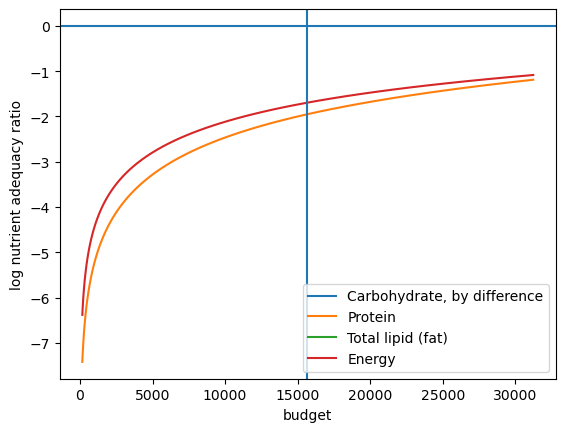

In [31]:
X = np.geomspace(.01*xref,2*xref,100)

fig,ax = plt.subplots()

pd.DataFrame({x:np.log(nutrient_adequacy_ratio(x,pbar,dbar))[UseNutrients] for x in X}).T.plot(ax=ax)

ax.legend(UseNutrients)
ax.set_xlabel('budget')
ax.set_ylabel('log nutrient adequacy ratio')
ax.axhline(0)
ax.axvline(xref)

Text(0.5, 0, 'log nutrient adequacy ratio')

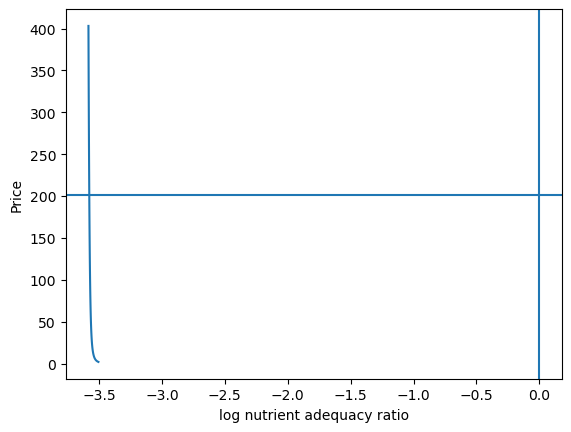

In [32]:
scale = np.geomspace(.01,2,50)

ndf = pd.DataFrame({s*pbar[USE_GOOD]:np.log(nutrient_adequacy_ratio(xref/4,ceteris_paribus_price(USE_GOOD,pbar[USE_GOOD]*s),dbar))[UseNutrients] for s in scale}).T

fig,ax = plt.subplots()
ax.plot(ndf['Protein'],ndf.index)
ax.axhline(pbar[USE_GOOD])
ax.axvline(0)

ax.set_ylabel('Price')
ax.set_xlabel('log nutrient adequacy ratio')

# Nutritional Adequacy & Policy Goals

In [37]:
adequacy = N.div(hh_rdi, axis=0)

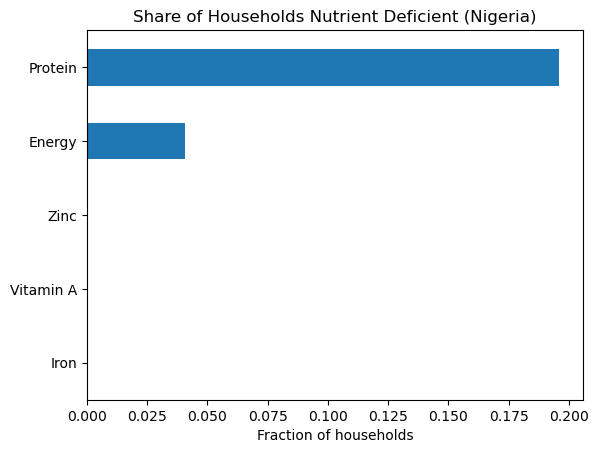

In [34]:
nutrients = ['Energy', 'Protein', 'Vitamin A', 'Iron', 'Zinc']

deficiency_rates = (adequacy.loc[nutrients] < 1).mean(axis=1)

deficiency_rates.sort_values().plot(kind='barh')
plt.title("Share of Households Nutrient Deficient (Nigeria)")
plt.xlabel("Fraction of households")
plt.show()

This graph shows the fraction of households that fail to meet recommended nutrient intake levels. We see that protein deficiency is the most widespread, affecting roughly 20% of households, while calorie deficiency is much lower. This suggests that the main issue is not total food consumption, but diet composition. Households are getting enough calories but not enough protein.

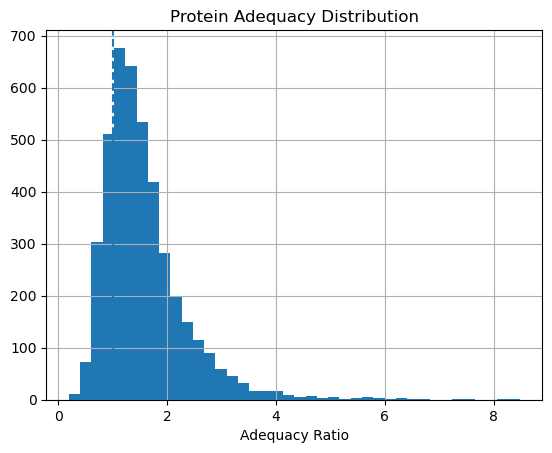

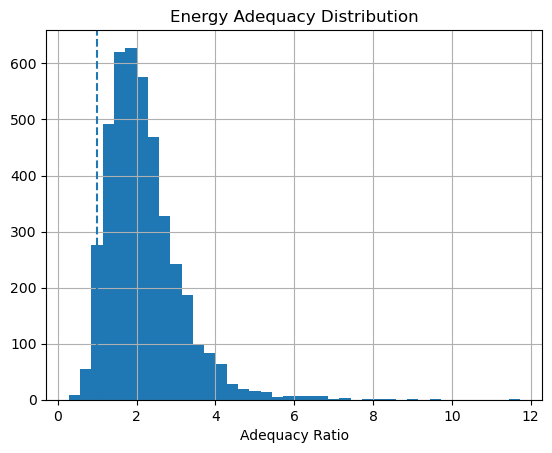

In [35]:
for nutrient in ['Protein', 'Energy']:
    adequacy.loc[nutrient].hist(bins=40)
    plt.axvline(1, linestyle='--')
    plt.title(f"{nutrient} Adequacy Distribution")
    plt.xlabel("Adequacy Ratio")
    plt.show()

While most households meet protein requirements, there is a significant left tail of households that fall below adequacy. This indicates inequality in access to protein-rich foods, rather than a universal shortage

Energy adequacy is generally high across households, with most consuming well above required calorie levels. This reinforces that calorie deficiency is not the primary issue; instead, the challenge lies in nutrient quality.

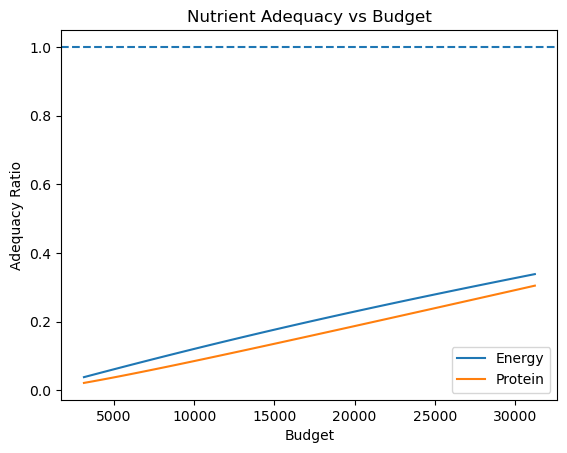

In [36]:
X = np.linspace(xref/5, xref*2, 50)

df = pd.DataFrame({
    x: nutrient_adequacy_ratio(x, pbar, dbar)[['Energy','Protein']]
    for x in X
}).T

df.plot()
plt.axhline(1, linestyle='--')
plt.title("Nutrient Adequacy vs Budget")
plt.xlabel("Budget")
plt.ylabel("Adequacy Ratio")
plt.show()

We observe that nutrient adequacy increases with household budget, indicating that income constraints play a role in nutritional outcomes. However, even at higher budget levels, households do not fully meet recommended protein and energy requirements. This suggests that increasing income alone may not fully solve nutritional deficiencies, and that food prices and dietary choices also play an important role.

### Summary

Our analysis shows that protein deficiency is the most significant nutritional challenge in Nigeria, affecting a substantial share of households, while calorie deficiency is relatively low. Distributional analysis reveals that while most households meet basic energy needs, a subset remains significantly protein deficient, indicating inequality in diet quality. Furthermore, nutrient adequacy improves with income, but does not reach recommended levels even at higher budgets. This suggests that both income constraints and food access or pricing issues contribute to persistent nutritional deficiencies.

### Cash Transfers

In [38]:
nutrient_adequacy_ratio(1.2 * xref, pbar, dbar)

Alanine                         NaN
Alcohol, ethyl                  NaN
Amino acids                     NaN
Arginine                        NaN
Ash                             NaN
                                 ..
Vitamin K (phylloquinone)       NaN
Vitamins and Other Components   NaN
Water                           NaN
Zinc                            NaN
Zinc, Zn                        NaN
Length: 164, dtype: float64

### Food Subsidies

In [41]:
new_prices = pbar.copy()
new_prices[['Eggs','Brown beans']] *= 0.8

nutrient_adequacy_ratio(xref, new_prices, dbar)

Alanine                         NaN
Alcohol, ethyl                  NaN
Amino acids                     NaN
Arginine                        NaN
Ash                             NaN
                                 ..
Vitamin K (phylloquinone)       NaN
Vitamins and Other Components   NaN
Water                           NaN
Zinc                            NaN
Zinc, Zn                        NaN
Length: 164, dtype: float64

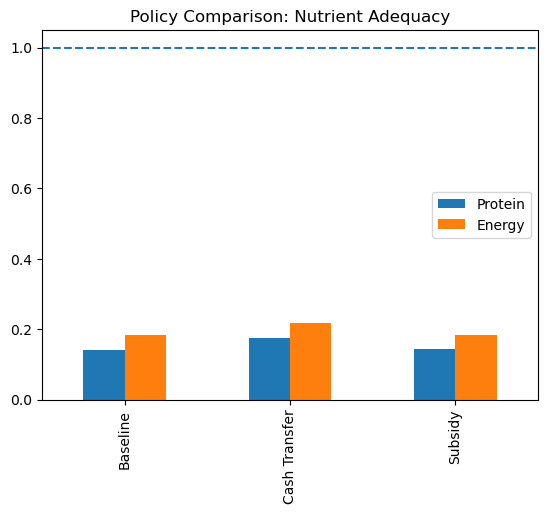

In [42]:
baseline = nutrient_adequacy_ratio(xref, pbar, dbar)
cash = nutrient_adequacy_ratio(1.2*xref, pbar, dbar)
subsidy = nutrient_adequacy_ratio(xref, new_prices, dbar)

df = pd.DataFrame({
    'Baseline': baseline[['Protein','Energy']],
    'Cash Transfer': cash[['Protein','Energy']],
    'Subsidy': subsidy[['Protein','Energy']]
}).T

df.plot(kind='bar')
plt.axhline(1, linestyle='--')
plt.title("Policy Comparison: Nutrient Adequacy")
plt.show()

Our policy simulations suggest that both cash transfers and food subsidies can improve nutritional outcomes, but neither is sufficient to fully eliminate deficiencies. Cash transfers increase overall consumption and have a broader effect on both energy and protein intake, while targeted subsidies improve access to specific nutrients but may be limited by substitution patterns and dietary preferences. Combined with earlier evidence that nutrient adequacy increases with income but remains below recommended levels, these results indicate that improving nutrition in Nigeria requires a multifaceted approach that addresses both income constraints and structural barriers such as food prices and access to nutrient-dense foods.